## Colab 환경에서 실행 시 환경 설정

In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

#### 코랩에서 한국어 표시하기

In [ ]:
!pip install koreanize-matplotlib

In [1]:
import koreanize_matplotlib

# 🔖 자연어 처리 기초2

<a id="lecture_index"></a>
## 수업 목차 

[1. 복습](#one)<br>
- 텍스트 데이터의 특징 
- 텍스트 데이터의 처리 과정 
- 규칙기반 자연어 처리 
- 통계기반 자연어 처리 

[2. 통계기반 자연어 처리](#two)<br>
- Bag of Words
- TF-IDF

[3. 분산표현과 신경망](#three)<br>
- 워드 임베딩의 개념 
- Word2Vec

[4. 순환 신경망](#four)<br>
- RNN 모델 특징 
- RNN 구조 수식 및 시각화 
- PyTorch로 구현하기


## <a id='one'>1️⃣ 복습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 🧩 Quiz 1

## <a id='two'>2️⃣ 통계기반 자연어 처리</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

> 통계 기반 NLP는 코퍼스를 통해 단어의 빈도, 동시 발생 빈도 등을 기반으로 처리를 함 <br> 
> 💡 통계적 언어 모델의 핵심 아이디어: 단어의 의미는 주변 단어로 알 수 있다 

## 텍스트 데이터 단위 

<img src="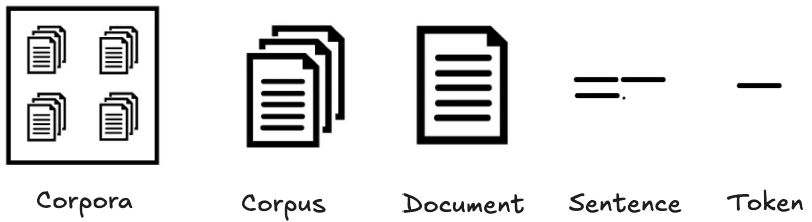
" width="1100" height="350"/>

1. Corpora <br>
: 여러개의 Corpus <br>
예) 다국어 번역 모델 Corpora [영어-한국어 번역 corpus, 한국어-일본어 번역 corpus, 등...]

2. Corpus <br>
: 자연어 문서들의 집합. 모델 학습용으로 수집된 텍스트 데이터 전체. <br>
예) 뉴스 기사 모음, 나무위키 데이터 모음, SNS 글 모음 <br>
⚠️ 단순히 텍스트의 모음이 아니라 품사 태그가 붙거나 텍스트에 라벨이 붙은 데이터도 전부 corpus라 부름 <br>
(raw corpus, annotated corpus, cleaned corpus 등..)

3. Document <br>
: Corpus를 구성하는 개별 문서. <br>
예) 뉴스 기사 하나, 나무위키 검색으로 보이는 페이지 하나, SNS 게시글 하나 <br>

4. Sentence <br> 
: Corpus를 구성하는 개별 문장. <br> 
  분석 목적에 따라 텍스트를 Document 대신 Sentence 단위로 지정하기도 함 <br> 
예) 두 문장의 유사도 분석이 필요한 경우

5. Token <br>
: 문장에서 의미 있는 최소 단위의 단어. <br>
예) "나는 비빔 인간입니다" -> 나, 비빔, 인간, 입니다 또는 나는, 비빔, 인간입니다 등...  <br>
⚠️ 토큰화는 목적에 따라 달라질 수 있음 

## Bag of Words 

> 문장을 단어의 집합(가방)으로 보고, 순서와 상관 없이 등장 횟수만 고려하는 방식 <br>
> 단어 목록을 만들고 이를 기반으로 문장을 벡터화 하는 과정까지 포함한다

### ✅ 특징 

#### ① 간단하고 빠른 처리가 가능 
#### ② 희소(sparse) 벡터가 만들어짐 
#### ③ 문맥을 고려하지 않음

In [1]:
from konlpy.tag import Okt
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
corpus1 = ["나는 비빔 인간입니다.", "나는 비빔밥을 좋아합니다.", "저는 파스타를 좋아합니다."]
corpus2 = ["오늘 날씨 매우 매우 좋다", "내일은 비 온다", "나는 날씨가 싫다"]

In [2]:
import MeCab

tagger = MeCab.Tagger()
print(tagger.parse("안녕하세요. 만나서 반가워요."))


안녕	NNG,행위,T,안녕,*,*,*,*
하	XSV,*,F,하,*,*,*,*
세요	EP+EF,*,F,세요,Inflect,EP,EF,시/EP/*+어요/EF/*
.	SF,*,*,*,*,*,*,*
만나	VV,*,F,만나,*,*,*,*
서	EC,*,F,서,*,*,*,*
반가워요	VA+EF,*,F,반가워요,Inflect,VA,EF,반갑/VA/*+어요/EF/*
.	SF,*,*,*,*,*,*,*
EOS



In [2]:
import MeCab

def mecab_morphs(text):
    tagger = MeCab.Tagger()
    # 문장을 노드 객체로 파싱
    node = tagger.parseToNode(text)

    morphs = []
    while node:
        if node.feature.startswith('NNG') or node.feature.startswith('NNP') or node.feature.startswith('VA') or node.feature.startswith('VV'):
            morphs.append(node.surface)  # 형태소만 추출
        node = node.next

    return morphs

# 예시 문장
text = "안녕하세요. 만나서 반가워요."
print(mecab_morphs(text))


['안녕', '만나', '반가워요']


In [12]:
mecab_morphs("안녕하세요. 만나서 반가워요.")

['안녕', '하', '세요', '.', '만나', '서', '반가워요', '.']

In [9]:
okt = Okt()

In [10]:
okt.morphs("안녕하세요. 만나서 반가워요.")

['안녕하세요', '.', '만나서', '반가워요', '.']

N-gram
["안녕 나는 사람이야"]
"안녕"
"나는"
"사람이야"
"안녕 나는"
"나는 사람이야"
"안녕 사람이야"

In [4]:
mecab = Okt() 

def mecab_tokenizer(text):
    return mecab.morphs(text)

def custom_preprocessor(text):
    return text.replace('.', '')

korean_stopwords = ['는', '을', '를', '이', '가', '저는', '나는', '입니다', '합니다']

# 처리 순서 1. preprocessor 2. tokenizer 3. 불용어 처리 4. ngram 적용 5. 단어 빈도 계산 및 제거 6. 벡터 생성
vectorizer = CountVectorizer(tokenizer=mecab_tokenizer,  # 사용자 지정 토크나이저 
                             stop_words=korean_stopwords, # 불용어 지정 
                             ngram_range=(1,2),  # n개 부터 m개 까지의 단어 묶음으로 만들기 -> 단어 사이의 문맥과 조합된 의미 반영을 위해
                             max_features=20, # 가장 많이 등장한 단어 개수 지정
                             min_df=1, # 최소 1개 문서에 등장한 단어만 사용 
                             max_df=0.8, # n% 이상 문서에 등장하면 제외 
                             lowercase=False, # 한글에는 적용 X 
                             preprocessor=custom_preprocessor,
                             token_pattern='(?u)\\b\\w\\w+\\b') # 여기에 쓰인 정규식 패턴으로 토큰을 분리 (기본값)
                             # (?u) -> 유니코드 모드(한글을 포함한 문자도 글자로 인식 할 수 있게 해줌)
                             # \b -> 띄어쓰기를 기준으로 단어의 시작 혹은 끝으로 인식 
                             # \w -> 글자 하나 (한글, 영어, 숫자, 밑줄 중 하나)
                             # \w\w+ -> 두 글자 이상 

In [5]:
tokens = vectorizer.fit_transform(corpus1 + corpus2)

c:\anaconda3\envs\tf\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\anaconda3\envs\tf\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['나', '저'] not in stop_words.
  warnings.warn(


In [6]:
tokens.toarray()

array([[1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1],
       [0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int64)

In [3]:
from datasets import load_dataset
import numpy as np

c:\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# 데이터셋
from datasets import load_dataset
import numpy as np


dataset = load_dataset('nsmc', trust_remote_code=True)
corpus = dataset['train']['document']


c:\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
len(corpus)

150000

In [34]:
corpus[10040]

'최근에 봤는데..색감도 너무 이쁘고..다 아는내용이지만 그래도 좋네요~'

In [36]:
okt = Okt()
okt.morphs(corpus[0][0:100]) # 형태소 분석기 사용 예시

['아', '더빙', '..', '진짜', '짜증나네요', '목소리']

In [5]:
token_list = []
corpus = corpus1 + corpus2
for sent in corpus:
    tokens = mecab.morphs(sent)
    token_list.append(tokens)

word_idx = {word: idx for idx, word in enumerate(set(token_list))}

vector = np.zeros(len(word_idx))

vectors = []
for sent in token_list:
    vector = np.zeros(len(word_idx))
    for word in sent:
        vector[word_idx[word]] += 1
    vectors.append(vector)

NameError: name 'corpus1' is not defined

In [22]:
import numpy as np

def tokenizer(document):
    return okt.morphs(document)

def bag_of_words1(corpus, tokenizer):
    # 토큰화
    token_list = [tokenizer(document) for document in corpus]
    token_list2 = [token for tokens in token_list for token in tokens] # 하나의 리스트에 토큰들이 나열열
    bow_ = set(token_list2) # bag of words
    bow = {word: idx for idx, word in enumerate(bow_)} # 단어와 인덱스 매칭

    vec_list = []
    for tokens in token_list:
        vec = np.zeros(len(bow))
        for token in tokens:
            if token in bow_:
                vec[bow[token]] += 1 # 해당 인덱스에 하나 카운트

        vec_list.append(vec)
        
    return vec_list

In [ ]:
data = bag_of_words(corpus, tokenizer)

In [51]:
data

[array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 

In [4]:
from itertools import chain

In [10]:
list(chain([1, 2, 3], [4, 5, 6])) # iterable 한 객체를 나열하면 하나의 리스트로 만들어줌

[1, 2, 3, 4, 5, 6]

In [34]:
list(chain.from_iterable([[1, 2, 3], [4, 5, 6]]))

[1, 2, 3, 4, 5, 6]

In [30]:
def tokenizer(document):
    return okt.morphs(document)

def bag_of_words2(corpus, tokenizer):
    # 토큰화
    token_list = [tokenizer(document) for document in corpus]
    token_list2 = list(chain.from_iterable(token_list))     # generator가 아니긴 하나, generator처럼 동작
    bow_ = set(token_list2) # bag of words
    bow = {word: idx for idx, word in enumerate(bow_)} # 단어와 인덱스 매칭

    vec_list = []
    for tokens in token_list:
        vec = np.zeros(len(bow))
        for token in tokens:
            if token in bow_:
                vec[bow[token]] += 1 # 해당 인덱스에 하나 카운트

        vec_list.append(vec)
        
    return vec_list

In [13]:
test = [[1, 2, 3], [4, 5, 6]]

In [14]:
sum(test, [])

[1, 2, 3, 4, 5, 6]

In [31]:
def tokenizer(document):
    return okt.morphs(document)

def bag_of_words3(corpus, tokenizer):
    # 토큰화
    token_list = [tokenizer(document) for document in corpus]
    token_list2 = sum(token_list, [])
    bow_ = set(token_list2) # bag of words
    bow = {word: idx for idx, word in enumerate(bow_)} # 단어와 인덱스 매칭

    vec_list = []
    for tokens in token_list:
        vec = np.zeros(len(bow))
        for token in tokens:
            if token in bow_:
                vec[bow[token]] += 1 # 해당 인덱스에 하나 카운트

        vec_list.append(vec)
        
    return vec_list

In [5]:
import time         # 시간 관련 모듈
import tracemalloc  # 메모리 사용량 관련 모듈

In [38]:
def benchmark(functions, *arg, **kwargs):

    results = []
    for func in functions:
        print(f"{func} 함수 실행중")

        # 메모리 추적
        tracemalloc.start()     # 이 코드 밑에 실행되는 함수의 메모리 사용량을 추적합니다.

        # 시간 추적
        start_time = time.time() 

        result = func(*arg, **kwargs)

        # 메모리 현재 사용량, 최고 사용량
        current, peak = tracemalloc.get_traced_memory()  # currnet: 현제 메모리 사용량(바이트)/ peak: 추적 시작 이후 최고 사용량 

        # 메모리 추적 종료
        tracemalloc.stop()

        # 시간 기록용
        end_time = time.time()
        duration = end_time - start_time

        results.append({
            'name': func.__name__,
            'duration': duration,
            'peak_memory': round(peak / 1024 / 1024, 3),
        })

    return results



In [41]:
result = benchmark([bag_of_words1, bag_of_words2, bag_of_words3], corpus[:50000], tokenizer)

<function bag_of_words1 at 0x000001C014C74E50> 함수 실행중
<function bag_of_words2 at 0x000001C015595AB0> 함수 실행중


KeyboardInterrupt: 

In [40]:
result

[{'name': 'bag_of_words1',
  'duration': 16.631478309631348,
  'peak_memory': 1688.931},
 {'name': 'bag_of_words2',
  'duration': 18.644367456436157,
  'peak_memory': 1688.505},
 {'name': 'bag_of_words3',
  'duration': 22.221171140670776,
  'peak_memory': 1688.4}]

#### ✅ Lazy Evaluation vs Eager Evaluation 

- Lazy Evaluation: 값을 지금 바로 계산하지 않고, 필요할 때마다 한 개씩 계산해서 리턴하는 방식 <br> 
- Eager Evaluation: 코드가 실행되면 바로 값을 만들어서 전체를 메모리에 저장하여 연산하는 방식  

In [28]:
# Eager 
squares = [x**2 for x in range(5)]

In [30]:
# Lazy Evaluation
squares = iter(x**2 for x in range(5))

In [31]:
squares

<generator object <genexpr> at 0x000001C4F50E7F40>

In [24]:
# 메모리 사용량을 최소화 하고 싶을때 (중간에 상태값을 저장하거나 수정할 일이 없을때)
def gen():
    yield 1
    yield 2

# 메모리 사용량을 최소화 하고 싶을때 + 상태값을 사용하고 싶을때
class DataLoader():
    def __in1it__(self): # None
        pass

    def __getitem__(self):
        pass

gen = gen()

In [23]:
type(gen)

generator

In [22]:
next(gen)

1

### 네이버 영화 리뷰 긍정/부정 분석 

In [6]:
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import MeCab
import re 
from itertools import chain
import numpy as np

# 1. 데이터 불러오기
dataset = load_dataset('nsmc', trust_remote_code=True) 
train_dataset = dataset['train']
test_dataset = dataset['test']

x_train = train_dataset['document']
y_train = train_dataset['label']

x_test = test_dataset['document']
y_test = test_dataset['label']

In [10]:
len(y_train)

15000

In [28]:
from konlpy.tag import Okt

okt = Okt()
def tokenizer(sentence):
    return okt.morphs(sentence)

stop_words = ['은', '는', '이', '가', '을', '를', '에', '게', '의', '도', '으로', '와', '한', '하', '고']

# 정규화
def preprocessor(sentence):     # 문장 단위로 처리
    # 반복되는 문자열을 하나로 축소
    sentence = re.sub(r'(\w+)\1+', r'\1', sentence)

    return sentence.strip()

vectorizer = CountVectorizer(tokenizer=tokenizer,
                             stop_words=stop_words,
                             ngram_range=(1, 2),
                             max_features=5000,
                             min_df=1,
                             max_df=0.8,
                             preprocessor=preprocessor)

In [29]:
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.fit_transform(x_test)

c:\anaconda3\envs\tf\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=300)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
lr.fit(x_train, y_train)
rf.fit(x_train, y_train)

In [ ]:
lr

In [18]:
rf

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = lr.predict(x_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.47      0.51      0.49       681
           1       0.56      0.53      0.55       819

    accuracy                           0.52      1500
   macro avg       0.52      0.52      0.52      1500
weighted avg       0.52      0.52      0.52      1500



In [25]:
# 예측
y_pred = np.around(rf.predict(x_test))
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

         0.0       0.30      0.49      0.38       447
         1.0       0.71      0.52      0.60      1053

    accuracy                           0.51      1500
   macro avg       0.51      0.51      0.49      1500
weighted avg       0.59      0.51      0.53      1500



bag of words
    빈도수로 파악

### TF-IDF

> Term Frequency - Inverse Document Frequency의 약자로, <br> 
> 한 문서 안에서 단어가 몇번 나왔는지, 여러 문서 중 이 단어가 얼마나 희귀한지를 고려하여 데이터를 벡터화 하는 방법 <br> 
> 흔한 단어는 가중치를 낮게, 자주 등장하지 않는 단어는 가중치를 높게 

✅ “자주 등장하지만 모든 문서에서 흔한 단어는 중요하지 않다.
드물게 등장하면서 특정 문서에 많이 나타나는 단어가 진짜 중요하다!”

<img src="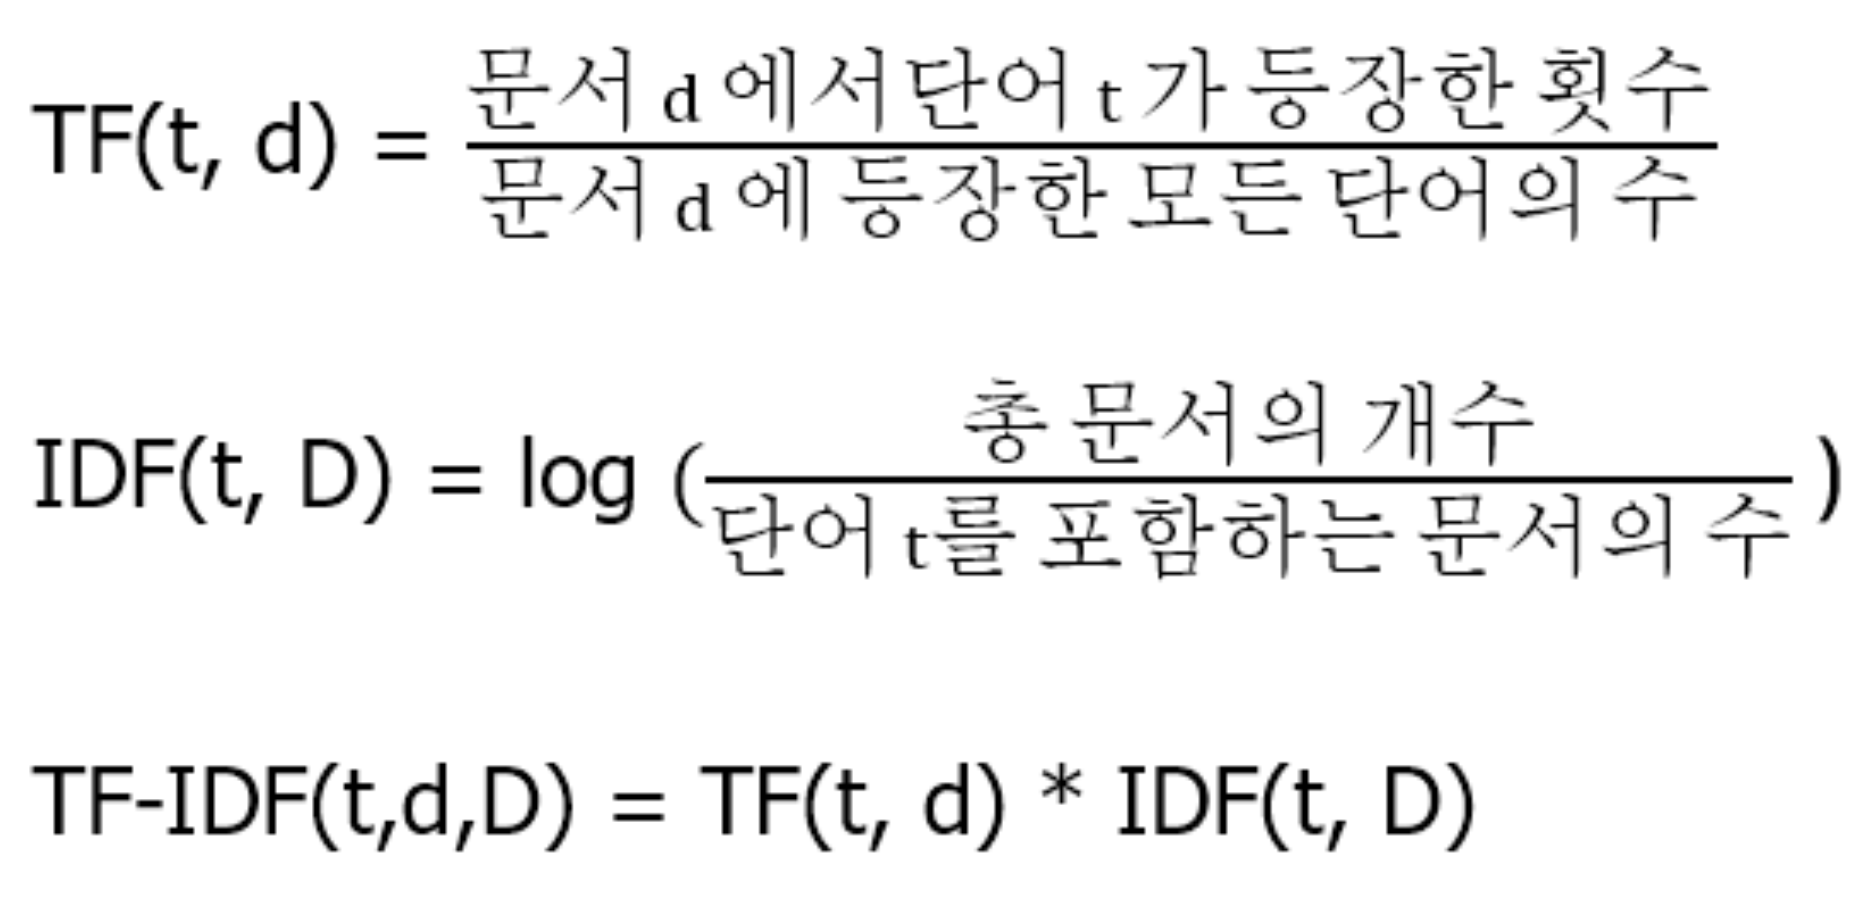
" width="680" height="350"/>

🛠️ log를 취하는 이유는 드물게 나오는 값의 크기가 너무 커지는 것을 방지하기 위해서 <br>
그리고 정보 이론에 따르면 어떤 단어가 드물게 등장할수록, 그 단어가 더 많은 정보를 담고 있다는 의미 이고, 
정보량은 아래와 같이 정의됨 

$$
\text{Information}(t) = -\log(P(t))
$$

출처: https://yeong-jin-data-blog.tistory.com/entry/TF-IDF-Term-Frequency-Inverse-Document-Frequency

### ✅ 특징 

#### ① 단순히 단어의 빈도 뿐만 아니라 전체 문서에서 얼마나 희귀한지도 반영함 <br>
 -> 정보량에 높은 가중치를 줌 (the, a, 은, 는, 이, 가 같이 빈번한 단어는 중요도를 낮게 봄)
#### ② 단어의 등장 위치는 고려하지 않음  
#### ③ 희소(sparse) 벡터가 만들어짐 

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from konlpy.tag import Okt

okt = Okt()
def tokenizer(sentence):
    return okt.morphs(sentence)

stop_words = ['은', '는', '이', '가', '을', '를', '에', '게', '의', '도', '으로', '와', '한', '하', '고']

# 정규화
def preprocessor(sentence):     # 문장 단위로 처리
    # 반복되는 문자열을 하나로 축소
    sentence = re.sub(r'(\w+)\1+', r'\1', sentence)

    return sentence.strip()

tfidfVectorizer = TfidfVectorizer(tokenizer=tokenizer,
                             stop_words=stop_words,
                             ngram_range=(1, 2),
                             max_features=5000,
                             min_df=1,
                             max_df=0.8,
                             preprocessor=preprocessor)

In [33]:
x_train = tfidfVectorizer.fit_transform(x_train)
x_test = tfidfVectorizer.fit_transform(x_test)

c:\anaconda3\envs\tf\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=300)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
lr.fit(x_train, y_train)
rf.fit(x_train, y_train)

In [ ]:
y_pred = lr.predict(x_test)
print(classification_report(y_pred, y_test))
# 예측
y_pred = np.around(rf.predict(x_test))
print(classification_report(y_pred, y_test))

In [9]:
import math
from collections import Counter, defaultdict

In [13]:
corpus = [
    "나는 밥을 먹었다",
    "너는 김치를 좋아한다",
    "밥과 김치를 먹고 산책했다"
]

In [ ]:
math.log()      # 밑이 e인 로그 / 0은 연산불가가

In [ ]:
test = [1, 2, 3, 4, 5, 1, 2, 3, 6, 8 ,10]

In [ ]:
test_cnt = Counter(test)

In [ ]:
test_cnt

In [10]:
ddict = defaultdict(int)

In [11]:
ddict['a']      # 값이 없는 key값에는 0을 반환

        # ddict['a'] += 1 없는 key 값에 바로 연산 가능

0

In [20]:
def tokenizer(document):
    return okt.morphs(document)

def tfidfVec(corpus, tokenizer):
    # 토큰화
    token_list = [tokenizer(document) for document in corpus]

    tf_list = []
    vec_list = []
    wordCount = defaultdict(int)
    doc_count = len(corpus)

    for tokens in token_list:
        temp_list = {}

        count = len(tokens)
        token = Counter(tokens)
    
        for i in token.keys():
            wordCount[i] += 1
        
        for k, v in token.items():
            tf = v / count
            temp_list[k] = tf

        tf_list.append(temp_list)

    for items in tf_list:
        temp_arr = []
        for k, v in items.items():
            idf = math.log(doc_count / wordCount[k])
            temp_arr.append(v * idf)
        
        vec_list.append(temp_arr)

    return vec_list

In [21]:
data = tfidfVec(corpus, tokenizer)

In [22]:
data

[[0.21972245773362198,
  0.08109302162163289,
  0.08109302162163289,
  0.21972245773362198,
  0.21972245773362198],
 [0.21972245773362198,
  0.08109302162163289,
  0.08109302162163289,
  0.08109302162163289,
  0.21972245773362198],
 [0.05792358687259491,
  0.15694461266687282,
  0.05792358687259491,
  0.05792358687259491,
  0.15694461266687282,
  0.15694461266687282,
  0.15694461266687282]]

In [15]:
okt = Okt()

In [16]:
tokenized_corpus = [tokenizer(document) for document in corpus]

In [17]:
tokenized_corpus

[['나', '는', '밥', '을', '먹었다'],
 ['너', '는', '김치', '를', '좋아한다'],
 ['밥', '과', '김치', '를', '먹고', '산책', '했다']]

In [26]:
tf_list = []
for doc in tokenized_corpus:
    dt = Counter(doc)
    total = len(doc)
    tf = {token: value/total for token, value in dt.items()}
    tf_list.append(tf)

In [27]:
tf_list

[{'나': 0.2, '는': 0.2, '밥': 0.2, '을': 0.2, '먹었다': 0.2},
 {'너': 0.2, '는': 0.2, '김치': 0.2, '를': 0.2, '좋아한다': 0.2},
 {'밥': 0.14285714285714285,
  '과': 0.14285714285714285,
  '김치': 0.14285714285714285,
  '를': 0.14285714285714285,
  '먹고': 0.14285714285714285,
  '산책': 0.14285714285714285,
  '했다': 0.14285714285714285}]

In [ ]:
total_doc = len(tokenized_corpus)

In [23]:
total_doc = len(tokenized_corpus)
df = defaultdict(int)
for doc in tokenized_corpus:
    for token in set(doc):
        df[token] += 1

In [24]:
idf = {token: math.log(total_doc / value) for token, value in df.items()}

In [25]:
idf

{'먹었다': 1.0986122886681098,
 '나': 1.0986122886681098,
 '는': 0.4054651081081644,
 '을': 1.0986122886681098,
 '밥': 0.4054651081081644,
 '너': 1.0986122886681098,
 '를': 0.4054651081081644,
 '좋아한다': 1.0986122886681098,
 '김치': 0.4054651081081644,
 '과': 1.0986122886681098,
 '산책': 1.0986122886681098,
 '먹고': 1.0986122886681098,
 '했다': 1.0986122886681098}

In [29]:
tf_idfs = []
for tf in tf_list:
    tf_idf = {token: value * idf[token] for token, value in tf.items()}
    tf_idfs.append(tf_idf)

In [30]:
tf_idfs

[{'나': 0.21972245773362198,
  '는': 0.08109302162163289,
  '밥': 0.08109302162163289,
  '을': 0.21972245773362198,
  '먹었다': 0.21972245773362198},
 {'너': 0.21972245773362198,
  '는': 0.08109302162163289,
  '김치': 0.08109302162163289,
  '를': 0.08109302162163289,
  '좋아한다': 0.21972245773362198},
 {'밥': 0.05792358687259491,
  '과': 0.15694461266687282,
  '김치': 0.05792358687259491,
  '를': 0.05792358687259491,
  '먹고': 0.15694461266687282,
  '산책': 0.15694461266687282,
  '했다': 0.15694461266687282}]

In [31]:
tf_idf_vals = [x.values() for x in tf_idfs]

In [32]:
tf_idf_vals

[dict_values([0.21972245773362198, 0.08109302162163289, 0.08109302162163289, 0.21972245773362198, 0.21972245773362198]),
 dict_values([0.21972245773362198, 0.08109302162163289, 0.08109302162163289, 0.08109302162163289, 0.21972245773362198]),
 dict_values([0.05792358687259491, 0.15694461266687282, 0.05792358687259491, 0.05792358687259491, 0.15694461266687282, 0.15694461266687282, 0.15694461266687282])]

##### TF-IDF의 단점
- 문장 내에서 단어간의 유사성을 표현하지 못했다. (문맥)
- 다의어 표현이 어렵다
- 순서를 알 수 없다.
- 희소 백터 형태를 띈다. (쓸데없이 차원이 늘어나서 연산량이 많아진다) - 입력 사이즈를 맞추기 위해 모자란 부분을 전부 0으로 채움 

### 🧩 Quiz 2

### NSMC 데이터셋을 활용한 감정 분류 모델 구현하기

1. 데이터는 Huggingface datasets 라이브러리를 사용하여 불러오세요.
2. 훈련 데이터와 검증 데이터를 8:2 비율로 나누세요.
3. TfidfVectorizer를 사용하여 문장을 벡터화하세요.
   (불용어 제거와 간단한 전처리 포함)
4. 분류기는 LogisticRegression을 사용하세요.
5. 예측 정확도를 출력하세요.

In [ ]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. 데이터 불러오기
dataset = load_dataset('nsmc')
texts = dataset['train']['document']
labels = dataset['train']['label']

검증 정확도: 0.7778


## <a id='three'>3️⃣ 분산표현과 신경망</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 단어간의 유사성을 표현하는 방법

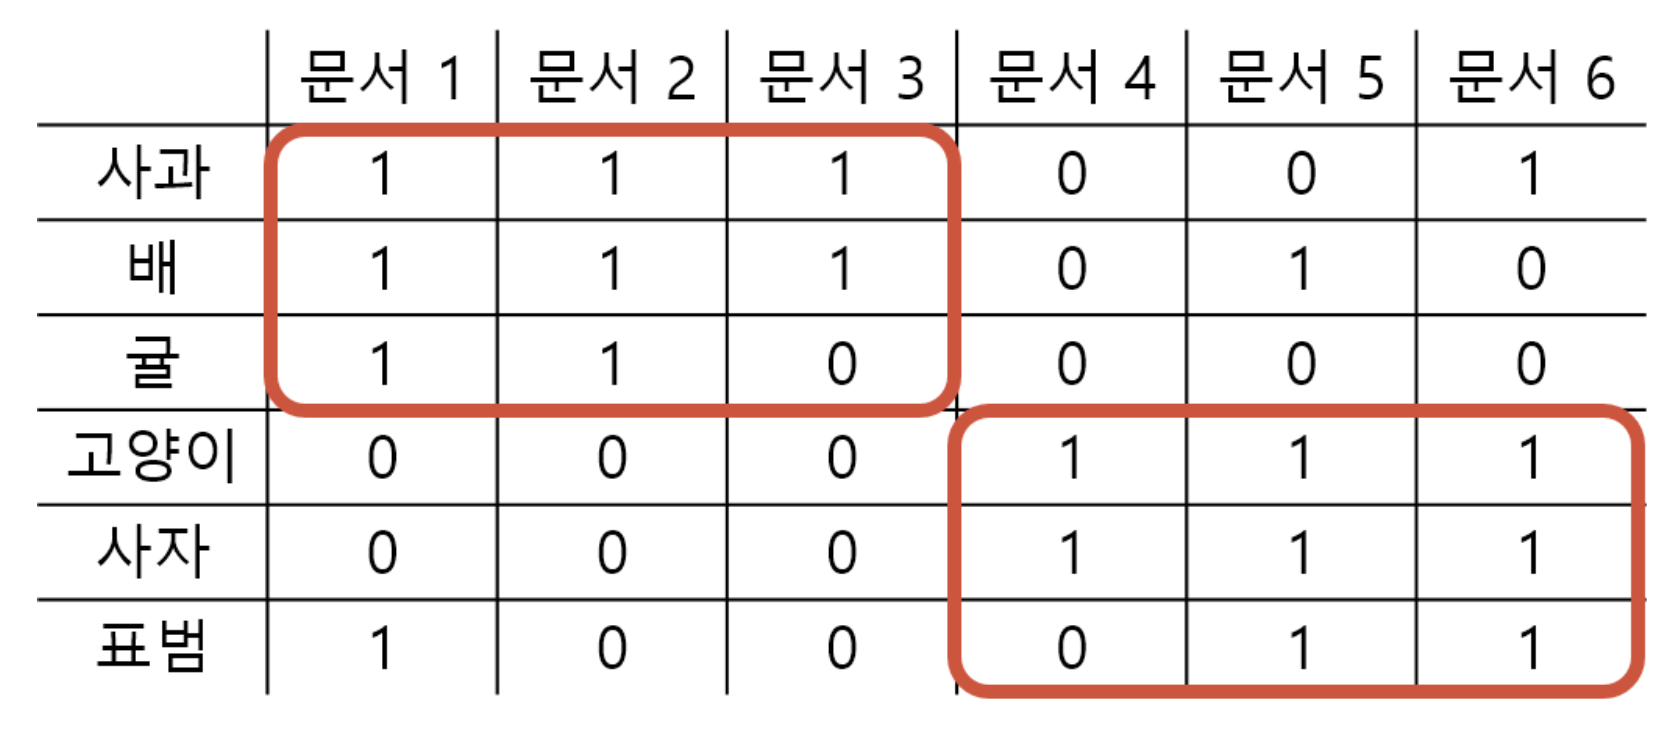

- 위 방식은 여러 문서가 있을 때 단어의 빈도를 통해 단어간의 유사성을 표현할 수 있음 
- 하지만, 단어의 유무로 벡터를 표현하기 때문에 벡터 자체가 단어의 의미를 내포하고 있지는 않음

<img src="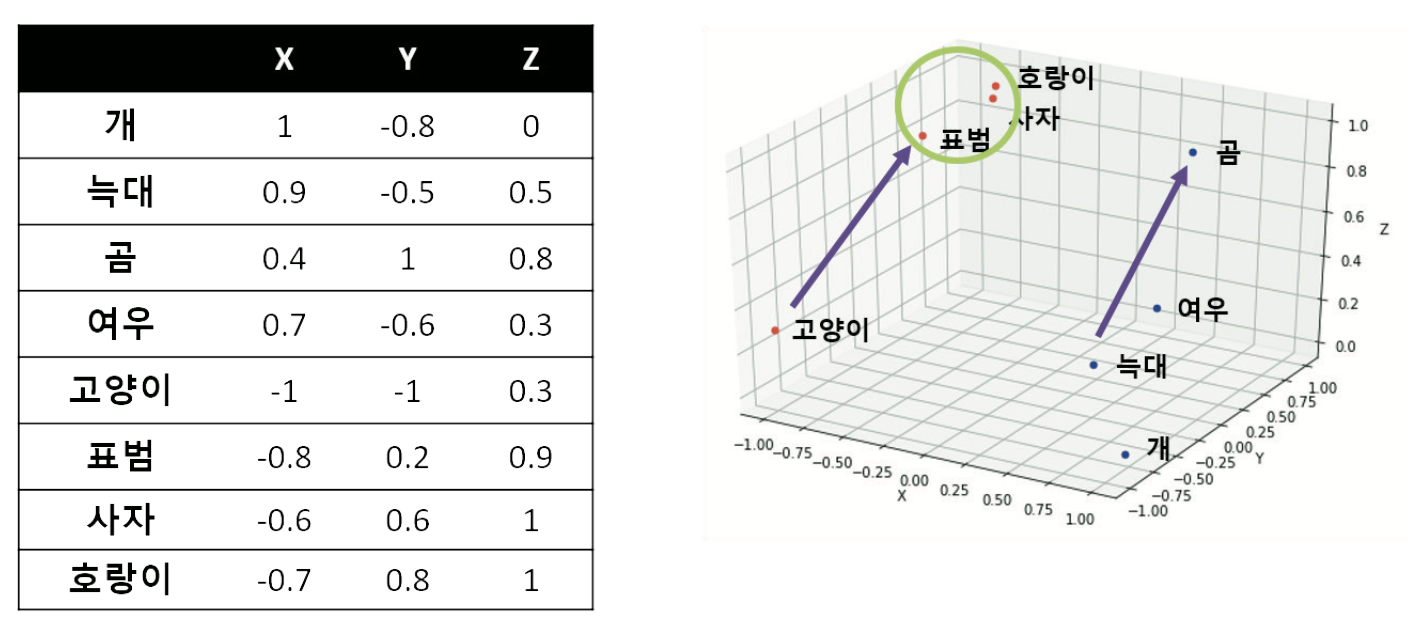
" width="750" height="400"/>

- 각 단어가 3차원 좌표 상의 한 점으로 표현 
- 좌표 상의 단순한 숫자(벡터)가 다른 단어와 함께 보면 즉, 문맥으로 보면 의미를 가짐 
- 비슷한 문맥에서 사용된 단어들일수록 비슷한 벡터 값을 가지게 됨

#### ✅ Word Embedding이란, 단어를 고정된 차원의 밀집 벡터로 변환하는 과정으로, 의미적으로 유사한 단어들이 벡터 공간 상에서 가깝도록 학습된다

👉 Embedding vector란, Word Embedding의 결과로 만들어진 단어 또는 토큰을 표현하는 벡터

### 🧐 어떻게 학습해야 Word Embedding을 만들 수 있는 걸까?

## Word2Vec

> 기존의 희소 벡터 방식의 한계를 극복하기 위해 만들어진 자연어 처리 기법 <br> 
> "비슷한 문맥에서 쓰이는 단어는 비슷한 의미를 가진다"는 분포 가설(Distributional Hypothesis)을 가정함 <br> 
> 주변 단어로 부터 중심 단어를 예측 하거나, 중심 단어로 부터 주변 단어를 예측하는 방식을 통해 단어를 의미 있는 벡터로 표현한다

<img src="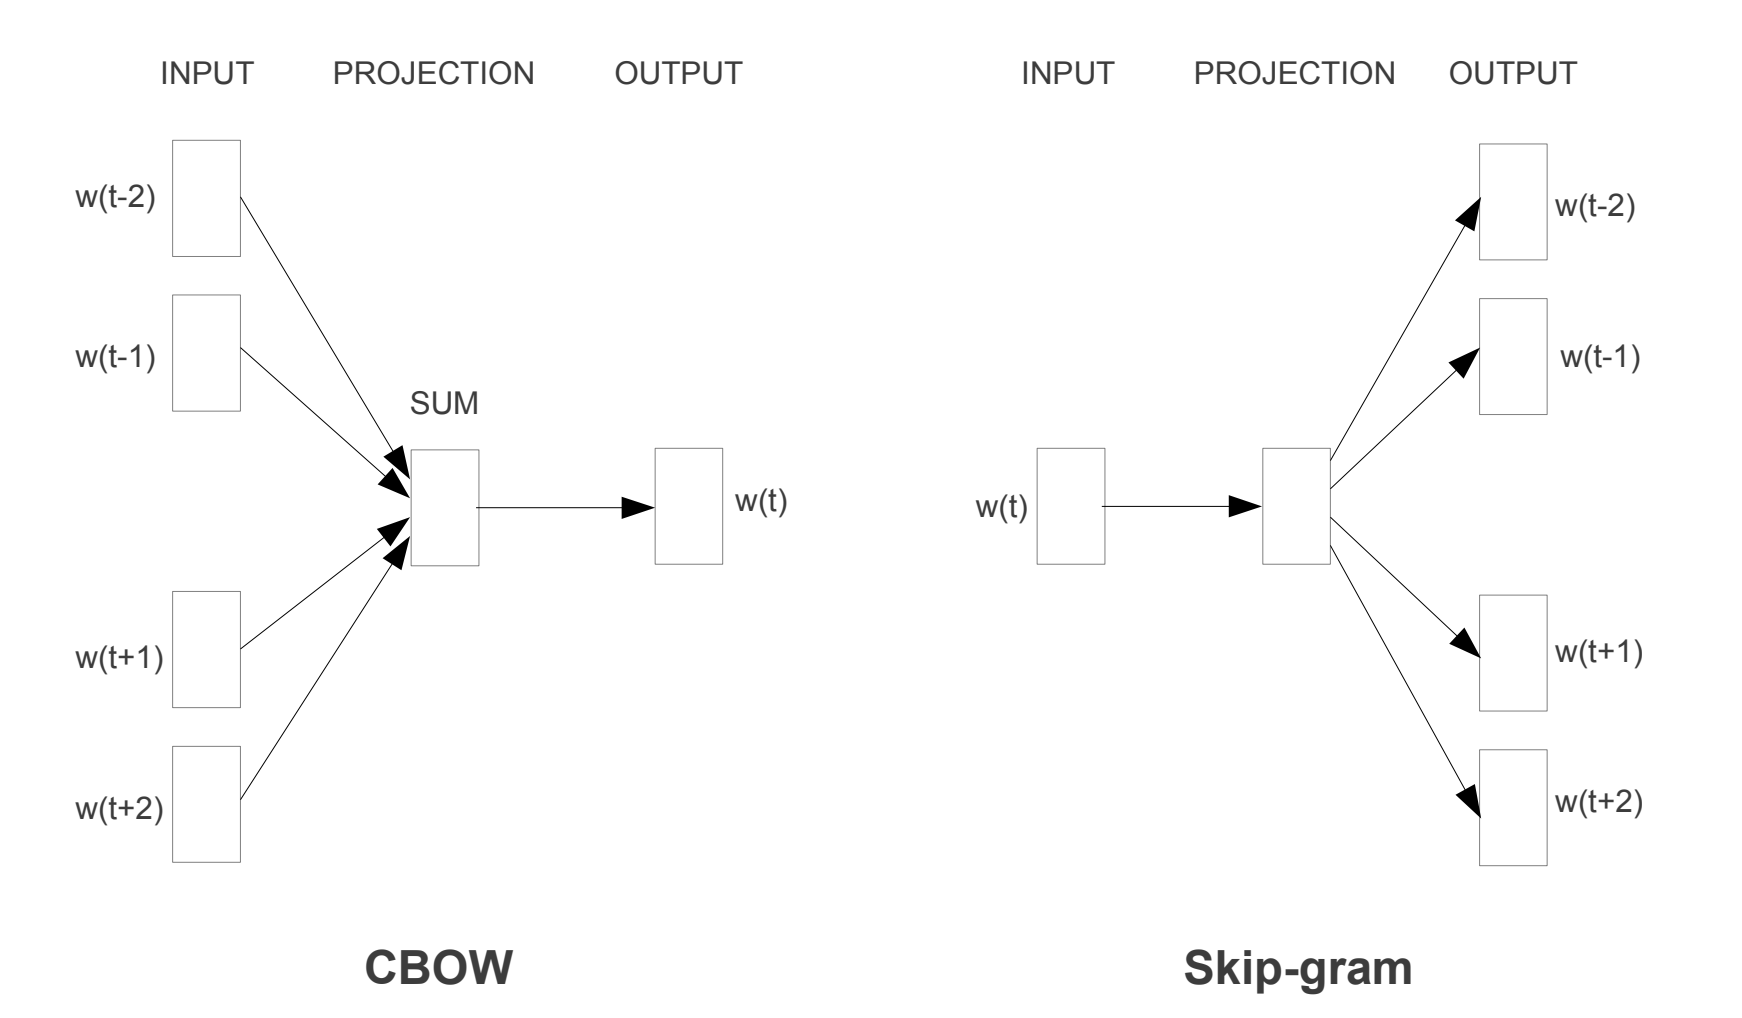
" width="650" height="400"/>

참고: https://arxiv.org/pdf/1301.3781

### CBOW (Continuous bag-of-word model)

> 앞 뒤 문맥을 보고 중심 단어를 유추하는 학습 방식

### Skip-gram

> CBOW와 반대. 중심 단어로 부터 이전 단어와 이후 단어를 유추하는 학습 방식

In [ ]:
# Skip - Gram

In [36]:
corpus = [
    "영화가 정말 좋았다",
    "스토리가 너무 지루했다",
    "연기는 좋았다",
    "최악의 영화 였다",
    "음악이 분위기를 살렸다",
    "배우 캐스팅이 최고다"
]

In [ ]:
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import MeCab
import re 
from itertools import chain
import numpy as np

# 1. 데이터 불러오기
dataset = load_dataset('nsmc', trust_remote_code=True) 
train_dataset = dataset['train']
test_dataset = dataset['test']

x_train = train_dataset['document']
y_train = train_dataset['label']

x_test = test_dataset['document']
y_test = test_dataset['label']

okt = Okt()
def extract_token(word):
    tokens = okt.morphs(word)
    return [token for token in tokens if len(token) > 1] # 두글자이상

tokenized_corpus = [extract_token(token) for token in x_train[:15000]]

# tokenized_corpus_train = [tokenizer(document) for document in x_train]
# tokenized_corpus_test = [tokenizer(document) for document in x_test]

In [40]:
from gensim.models import Word2Vec

In [73]:
model = Word2Vec(
    tokenized_corpus,
    vector_size=50,
    window=2,
    min_count=5,
    workers=2,
    epochs=5,
    sg=1
)

In [64]:
tokenized_corpus

[['더빙', '..', '진짜', '짜증나네요', '목소리'],
 ['...', '포스터', '보고', '초딩', '영화', '....', '오버', '연기', '조차', '가볍지', '않구나'],
 ['무재', '밓었', '다그', '래서', '보는것을', '추천'],
 ['교도소', '이야기', '구먼', '..', '솔직히', '재미', '없다', '..', '평점', '조정'],
 ['사이',
  '몬페',
  '익살스런',
  '연기',
  '돋보였던',
  '영화',
  '스파이더맨',
  '에서',
  '늙어',
  '보이기만',
  '했던',
  '커스틴',
  '던스트',
  '너무나도',
  '이뻐',
  '보였다'],
 ['걸음', '부터', '초등학교', '학년', '생인', '살용', '영화', 'ㅋㅋㅋ', '...', '반개', '아까'],
 ['원작', '긴장감', '제대로', '살려내지못', '했다'],
 ['반개',
  '아깝다',
  '나온다',
  '이응경',
  '길용우',
  '생활',
  '인지',
  '..',
  '정말',
  '해도',
  '그것',
  '보단',
  '낫겟다',
  '납치',
  '감금',
  '반복',
  '반복',
  '..',
  '드라마',
  '가족',
  '없다',
  '연기',
  '하는',
  '사람'],
 ['액션', '없는데도', '재미', '있는', '안되는', '영화'],
 ['왜케', '평점', '낮은건데', '..', '헐리우드', '화려함에만', '너무', '길들여져', '있나'],
 ['인피니트', '이다', '진짜', '이다'],
 ['볼때',
  '마다',
  '눈물나서',
  '죽겠다',
  '90년',
  '대의',
  '향수',
  '자극',
  '!!',
  '허진호',
  '감성',
  '절제',
  '멜로',
  '달인',
  '이다'],
 ['울면', '횡단보도', '건널', '쳐나', '이범수', '연기', '드럽게'],
 ['담백하고', '깔끔해서'

In [74]:
model.wv['진짜']

array([ 0.06043836,  0.06543392, -0.14985831,  0.10820291, -0.119539  ,
       -0.10943535,  0.21628302,  0.36531553, -0.43504462, -0.24628349,
       -0.01665337, -0.46098173,  0.27868527,  0.37600306, -0.22787713,
        0.29722258,  0.2905198 ,  0.16245213, -0.2997768 , -0.30685785,
        0.24512966,  0.23205791,  0.47072175, -0.03794103,  0.26823565,
        0.11860704, -0.05751379,  0.16616485, -0.45076793,  0.11196363,
        0.11036955, -0.18494926, -0.07326706, -0.15077041, -0.1115735 ,
        0.19066119,  0.2707888 ,  0.01094265,  0.04697461, -0.02290703,
        0.2158767 , -0.02163559, -0.0498361 ,  0.0406435 ,  0.5700961 ,
        0.06355011, -0.07130806, -0.36938313,  0.1918887 ,  0.07166047],
      dtype=float32)

In [81]:
model.wv.similarity("별로", "좋다")

0.9750539

In [75]:
model.wv.similarity("영화", "평점")

0.78827214

In [76]:
model.wv.similarity("영화", "감독")

0.8685059

In [77]:
model.wv.similarity("음악", "노래")

0.98174596

## PyTorch로 구현하기

In [ ]:
corpus = [
    "영화가 정말 좋았다",
    "스토리가 너무 지루했다",
    "연기는 좋았다",
    "최악의 영화 였다",
    "음악이 분위기를 살렸다",
    "배우 캐스팅이 최고다"
]

단어 가방 개수가 10

["단어": 0, "과일": 1, "사람": 2, "자동차": 3, "먹었다": 4]

사람이 과일을 먹었다

2 1 4

[중심단어, 주변단어] => [2, 1] / [1, 2] / [1, 4] / [4, 1] -> score가 1에 가까우면 loss 줄이고, 0에 가까우면 loss 늘림

In [116]:
from torch.utils.data import Dataset, DataLoader
from itertools import chain
from konlpy.tag import Okt
from itertools import product
import torch

okt = Okt()

class SkipGramDataset(Dataset):     # iterator는 하나씩 데이터를 뽑으면서 상태를 추가하거나 변경할 수 있다
    def __init__(self, corpus, window=2, vector_size=50):
        super().__init__()
        self.window = window
        self.vector_size = vector_size
        self.tokenized_corpus = self.tokenizer(corpus)
        self.bow = set(chain.from_iterable(self.tokenized_corpus))
        self.word2idx = {word:idx for idx, word in enumerate(self.bow)}
        self.center_context = self.make_center_context_pair(self.tokenized_corpus)


    def __len__(self):
        return len(self.center_context)

    def __getitem__(self, index):
        center, context = self.center_context[index]

        return torch.tensor(center, dtype=torch.float), torch.tensor(context, dtype=torch.float)

    def tokenizer(self, corpus):
        token_list = []
        for document in corpus:
            tokens = okt.morphs(document)
            token_list.append(tokens)

        return token_list

    def make_center_context_pair(self, tokenized_corpus):
        pairs = []

        for sentence in tokenized_corpus:
            indexs = [self.word2idx[word] for word in sentence if word in self.word2idx]
            for idx, center_word in enumerate(indexs):
                start = max(idx - self.window, 0)
                context_word = indexs[start:idx] + indexs[idx + 1: idx + self.window + 1]

                pairs += list(product([center_word], context_word))

        return pairs

In [117]:
dataset = SkipGramDataset(corpus)

In [118]:
dataset.center_context

[(4, 12),
 (4, 7),
 (12, 4),
 (12, 7),
 (12, 16),
 (7, 4),
 (7, 12),
 (7, 16),
 (16, 12),
 (16, 7),
 (14, 12),
 (14, 1),
 (12, 14),
 (12, 1),
 (12, 0),
 (1, 14),
 (1, 12),
 (1, 0),
 (0, 12),
 (0, 1),
 (3, 5),
 (3, 16),
 (5, 3),
 (5, 16),
 (16, 3),
 (16, 5),
 (2, 11),
 (2, 4),
 (11, 2),
 (11, 4),
 (11, 8),
 (4, 2),
 (4, 11),
 (4, 8),
 (8, 11),
 (8, 4),
 (18, 17),
 (18, 6),
 (17, 18),
 (17, 6),
 (17, 19),
 (6, 18),
 (6, 17),
 (6, 19),
 (6, 10),
 (19, 17),
 (19, 6),
 (19, 10),
 (10, 6),
 (10, 19),
 (9, 13),
 (9, 17),
 (13, 9),
 (13, 17),
 (13, 15),
 (17, 9),
 (17, 13),
 (17, 15),
 (15, 13),
 (15, 17)]

In [98]:
from itertools import product

In [104]:
list(product(["정말", "가"], ["영화"]))

[('정말', '영화'), ('가', '영화')]

In [105]:
list(product(["정말"], ["가", "영화"]))

[('정말', '가'), ('정말', '영화')]

In [108]:
dataset.center_context[0]

['영화', '가', '정말', '좋았다']

In [115]:
window = 2
center_idx = 2
start = max(0, center_idx - window)
dataset.center_context[0][start:center_idx]

['영화', '가']

In [114]:
dataset.center_context[0][center_idx + 1:center_idx + window + 1]

['좋았다']

In [113]:
dataset.center_context[0][start:center_idx] + dataset.center_context[0][center_idx + 1:center_idx + window + 1]

['영화', '가', '좋았다']

## <a id='four'>4️⃣ 순환 신경망</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## RNN (Recurrent Neural Network)

> RNN은 시계열, 문장, 음성 등 시퀀스 데이터(순서가 있는 데이터)를 처리하는 신경망 구조 <br> 
> 시간의 흐름에 따라 이전의 상태를 기억하며 정보를 반영함 <br> 
> 💡 "이전 시점의 출력을 현재의 입력과 함께 사용하여 현재의 출력을 만든다"

### ✅ RNN 모델 특징

#### ① 시퀀스 데이터 처리에 최적화 
- 입력의 순서 정보를 반영하는 구조 

#### ② 반복 구조 
- 하나의 RNN 셀을 시간 순서대로 반복하여 사용

#### ③ 파라미터 공유 
- 입력 시퀀스의 길이가 달라도 같은 파라미터를 사용하여 연산 

#### ④ 이전 정보 기억 유지 
- 이전 시점의 은닉 상태를 다음 시점 계산에 사용  

#### ⑤ 기울기 소실 문제 
- tanh 활성화 함수의 좁은 출력 범위
- 순환 구조로 인해 시간이 늘어날 수록 곱셈이 길어지는 문제 
- 과거에 중요한 정보를 기억하지 못하는 장기 의존성 문제가 발생함

#### ⑥ BPTT 
- 시간의 흐름에 따라 역전파를 수행하는 방식 
- 여러 시점의 데이터가 같은 가중치를 반복적으로 사용하기 때문에 각 시점의 미분 값을 누적하여 업데이트 함 
- 시퀀스가 일어질 수록 미분값이 점점 작아져 기울기 소실 문제에 취약함 
- 전체 시퀀스를 한 번에 처리 한 후 역전파를 수행하므로 순서를 학습 할 수 있음 

#### ⑦ 다양한 입/출력 구조 
- One to One 🧐 (의미 없음)
- Many to One ✅ 
- Many to Many (동일한 길이) ✅

⚠️ RNN 연산 시 입력 길이와 출력 길이는 항상 같다 

### RNN으로 해결 할 수 있는 문제들

입출력 구조|문제 유형|예시 입력|예시 출력|활용 사례
---|---|---|---|---
Many-to-One|시퀀스 분류|"시간 가는줄 모르고 봤습니다"|긍정/부정|감정분석, 뉴스 주제 분류, 스팸 분류
Many-to-One|시계열 예측|[30, 34, 35](3일간의 주식가격)|37|주식/날씨/신호 예측
Many-to-One|키워드 예측|"구글, 동영상 생성AI '비오2' 출시..."|AI|키워드 추출, 카테고리 분류
Maony-to-Many|시퀀스 라벨링|"충격! 정부가 드디어 발표한 내용은?"|[1, 1, 0, 0, 0, 0]|clickbait 단어 감지, 어조 변화 감지

### 사람이 문장을 이해하는 과정

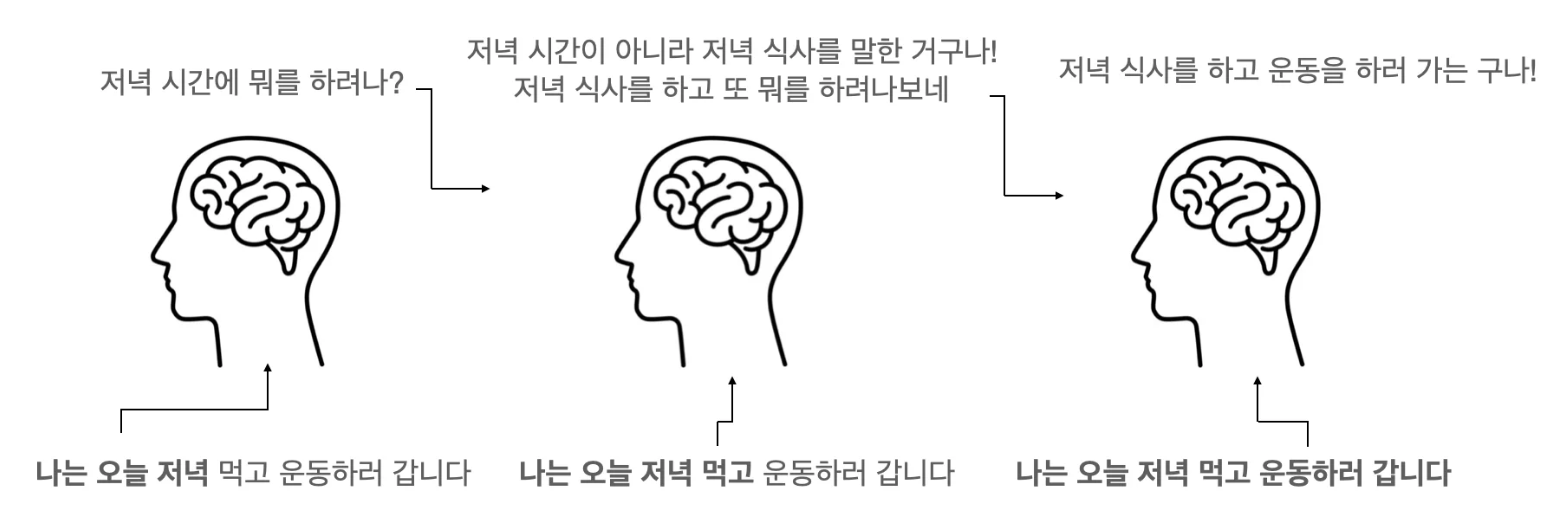

출처: https://aiheroes.ai/community/71

### RNN 구조 수식 및 시각화 

RNN은 입력 시퀀스를 처리할 때, **이전 상태(hidden state)**를 다음 입력과 함께 사용함

- 은닉 상태 수식:
  $$ h_t = \tanh(W_{h}h_{t-1} + W_{x}x_t + b) $$
- 출력 수식:
  $$ y_t = W_{y} h_t + b $$


✅ x_t: t 시점의 입력 시퀀스 데이터 <br>
✅ h_t-1: t-1 시점까지의 상태 데이터. 즉, 이전 까지의 입력 시퀀스가 담고 있던 의미나 패턴을 압축하여 표현한 벡터 <br>
✅ W_h: 이전 시점까지의 은닉 상태 가중치. 이전 까지의 입력 시퀀스가 현재 상태에 얼마나 영향을 줄지 결정하는 가중치 행렬 <br>
✅ W_x: 현재 시점의 은닉 상태 가중치. 현재 시점의 입력 시퀀스가 현재 상태에 얼마나 영향을 줄지 결정하는 가중치 행렬 <br>
✅ b: 바이어스. 입력과 과거 상태가 모두 0일 때도 일정한 출력을 유도할 수 있도록 도와주는 편향 벡터 

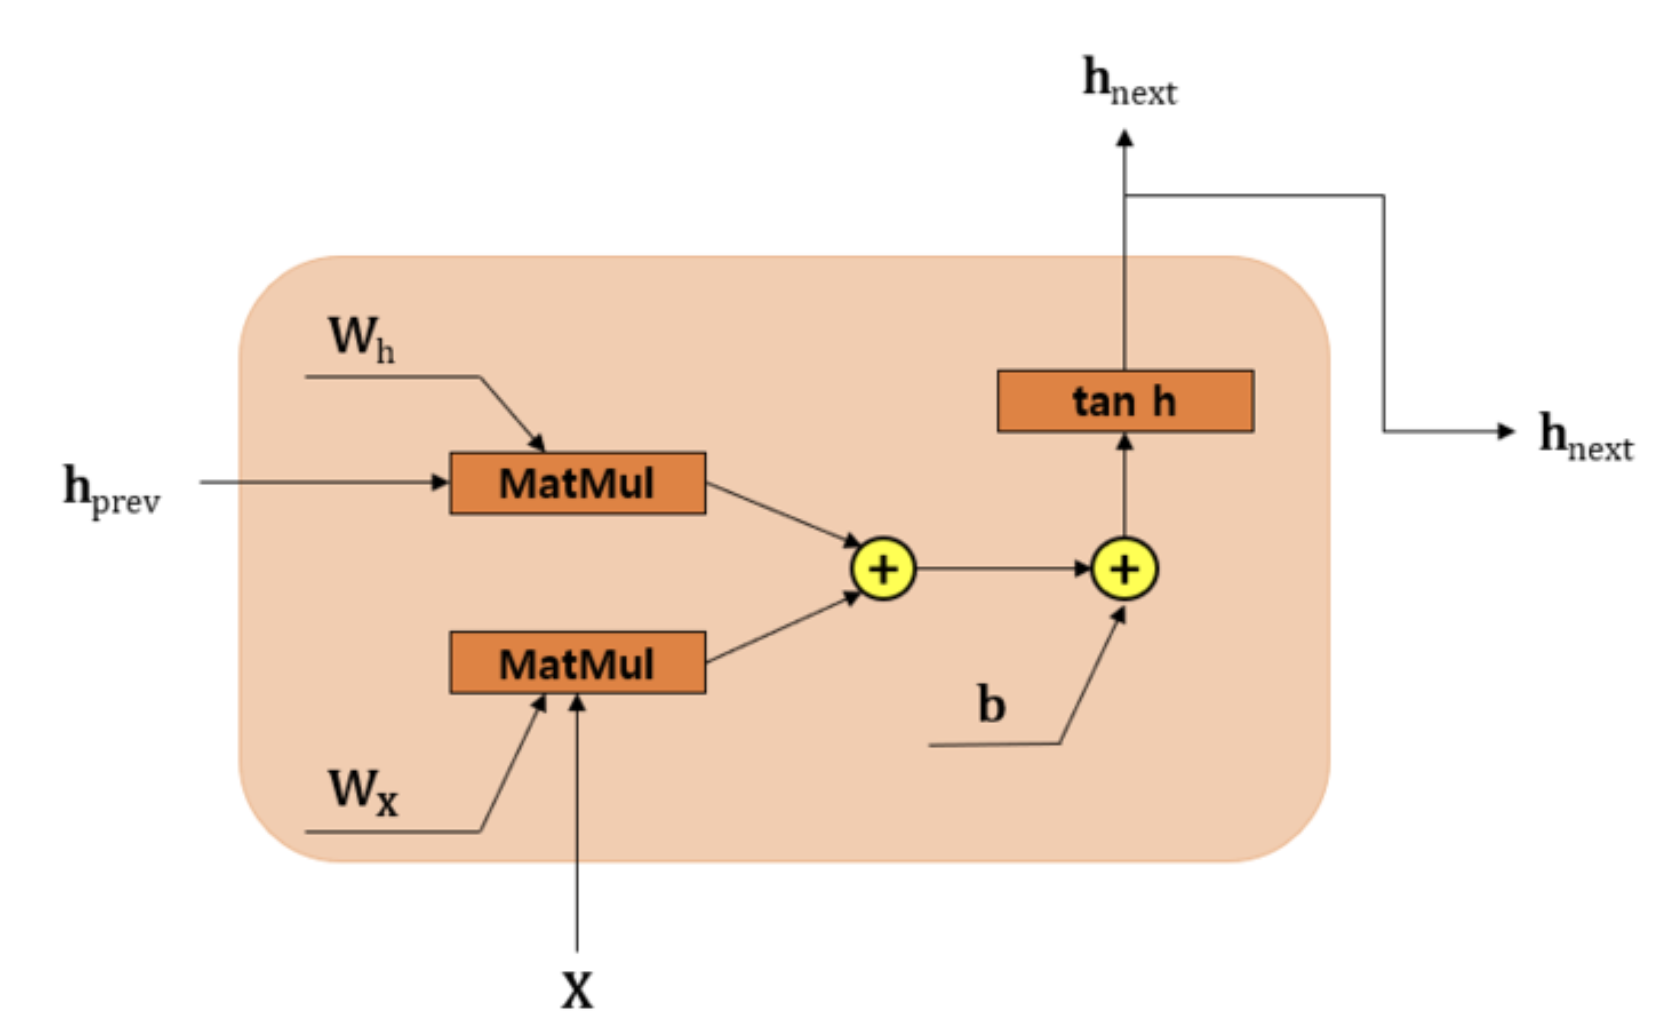

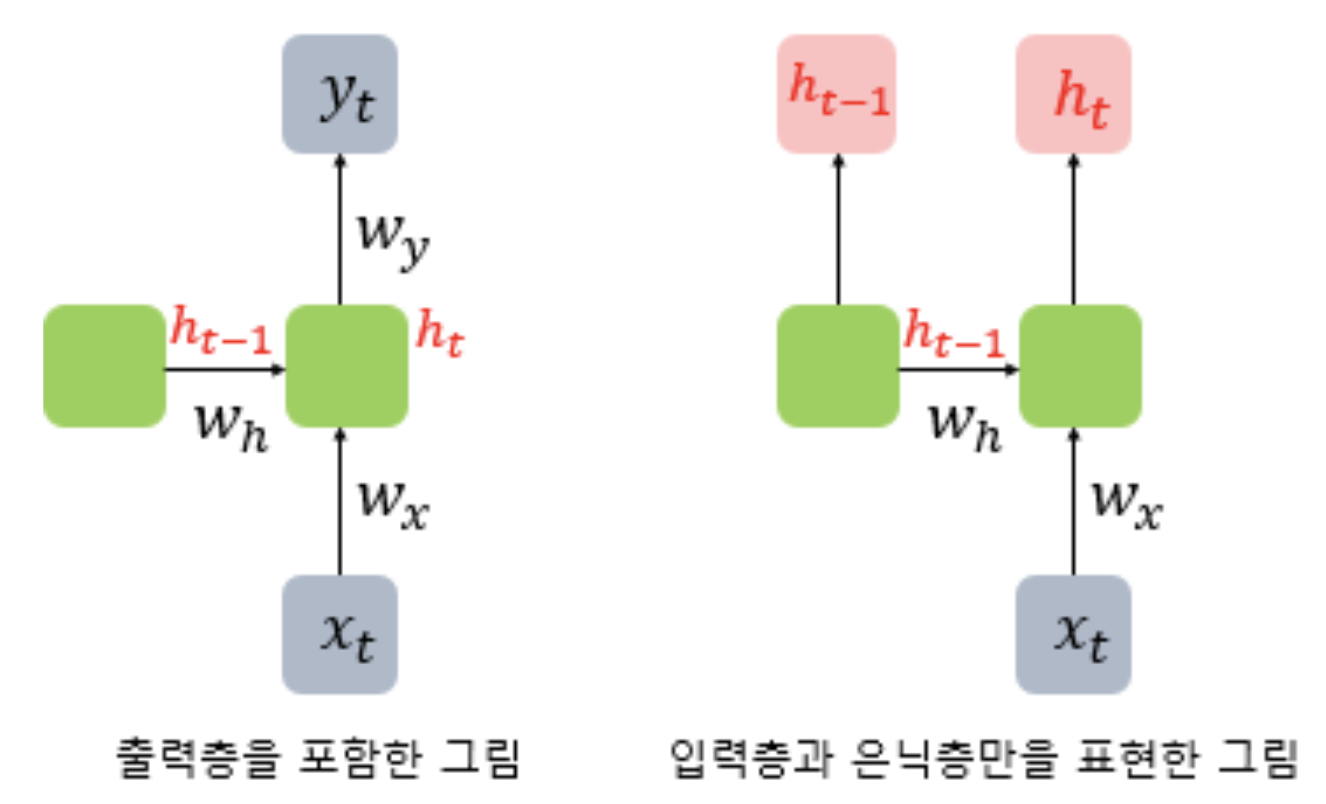

출처1: https://wikidocs.net/22886 <br>
출처2: https://sooftware.io/rnn/

### Numpy를 활용하여 쉽게 이해하기

### BPTT (Backpropagation Through Time)

> BPTT는 일반 신경망과는 달리 layer 별로 미분값(gradient)을 구해서 연산하지 않고, <br>
> 하나의 RNN 셀의 연산을 시간축으로 펼쳐서 미분값(gradient)을 구하여 같은 가중치에 누적반영 하는 시간 기반의 역전파 방식 

🛠️ leaf tensor: 학습 가능한 텐서. (requires_grad=True 이고, 연산을 통해 만들어지지 않는 텐서)

$$
\begin{align}
h_t &= \tanh(W x_t + U h_{t-1}) \\
y_t &= V h_t \\
L &= \sum_{t=1}^{T} \ell(y_t, target_t)
\end{align}
$$ 

$$
\begin{aligned}
\frac{\partial L}{\partial W} &= \sum_{t=1}^{T} \frac{\partial L_t}{\partial y_t} \cdot \frac{\partial y_t}{\partial h_t} \cdot \frac{\partial h_t}{\partial W} \\
\frac{\partial L}{\partial U} &= \sum_{t=1}^{T} \frac{\partial L_t}{\partial y_t} \cdot \frac{\partial y_t}{\partial h_t} \cdot \frac{\partial h_t}{\partial h_{t-1}} \cdot \frac{\partial h_{t-1}}{\partial U} \\
\frac{\partial L}{\partial V} &= \sum_{t=1}^{T} \frac{\partial L_t}{\partial y_t} \cdot \frac{\partial y_t}{\partial V}
\end{aligned}
$$

$$
\begin{aligned}
W &\leftarrow W - \eta \cdot \frac{\partial L}{\partial W} \\
U &\leftarrow U - \eta \cdot \frac{\partial L}{\partial U} \\
V &\leftarrow V - \eta \cdot \frac{\partial L}{\partial V}
\end{aligned}
$$

✅ W: 현재 상태를 반영하는 가중치 <br> 
✅ U: 이전 상태(기억)을 얼마나 반영할지를 조절하는 가중치 <br>
✅ V: 출력값으로 변환하기 위한 가중치 <br>
✅ η: 학습률


### backward vs retain grad with backward

> 학습가능한 파라미터만 미분값을 저장하며 학습하는 방식 vs 중간 결과값 같이 저장하며 학습하는 방식

### 💡 합산된 미분 값으로 가중치를 초기화 하는 이유는? 

- 평균을 내면 전체 맥락이 반영이 제대로 안될 수 있음 
- 누적으로 하면 흐름의 극적인 전환도 반영이 가능해짐 
- 예) 하루 기분, 계좌 잔고 

### Truncated BPTT

> 시퀀스가 길어질 때 발생하는 기울기 소실 문제나 학습 비효율 문제를 줄이기 위해, <br>
> 전체 시퀀스를 일정한 길이로 잘라서 구간 단위로 BPTT를 수행하는 방법 

### 🧩 Quiz 4

### RNN에서는 BPTT를 사용하는 이유가 무엇인가요?

### RNN과 ResNet의 공통점과 차이점을 각각 서술하시오.

### PyTorch로 구현하기

#### RNN 레이어 없이 직접 구현하기

#### RNN 레이어를 활용하여 구현하기

### 네이버 영화 리뷰 긍정/부정 분류 